In [5]:
from accessx.aoi import load_aoi, make_hex_grid
from accessx.graph import build_network, save_graph, load_graph
from accessx.cost import add_time_cost_constant_speed
from accessx.cost import add_slope_based_time, add_edge_cost
from accessx.isochrone import calculate_isochrones
from geopandas import read_file

## Define AOI & Create Hexagons

<Axes: >

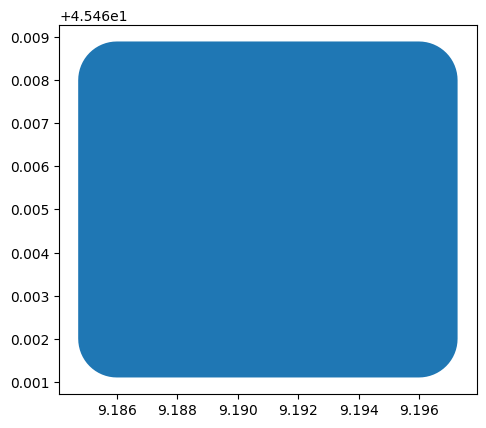

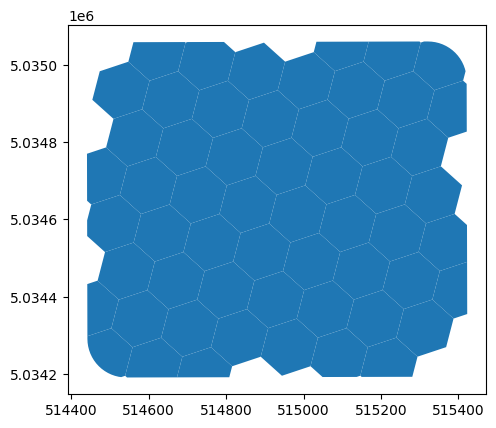

In [9]:
bbox_milano = (
    9.1860,   # minx (lon)
    45.4620,  # miny (lat)
    9.1960,   # maxx (lon)
    45.4680,  # maxy (lat)
)
city_epsg = 32632
buffer=100


aoi = load_aoi(bbox=bbox_milano, buffer_m=buffer, utm_crs=city_epsg, save_path="data/area/area_of_interest.geojson")
hexes = make_hex_grid(aoi,resolution=10, clip=True)
hexes_proj = hexes.to_crs(city_epsg)

aoi.plot()

hexes_proj.plot()

## Get street network

In [11]:

city_epsg = 32632
buffer=100

G_proj = build_network(
    AOI=aoi,
    city_epsg=city_epsg,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)


save_graph(
    G_proj,
    out_dir= "data/street_network/",
    base_name="original_graph",
    save_nodes=True,
    save_edges=True,
)



## Calculate cost per street segment 

### The cost can be the time to traverse a street based on a defined constant speed...

In [4]:

# time-cost based on costant speed defined by the user
G_proj = add_time_cost_constant_speed(G_proj, speed_kmh=4.5, cost_col="avg_time")


### ...or the time when using speed adjusted to the slope of the streets 
(in %, assuming slope_pct has been added to the graph)...

In [5]:

# custom cost defined by specific function that receives edge as input and returns cost
# example with function that returns time-cost based on slope-related speeds

G_proj = add_edge_cost(
    G_proj,
    cost_fn=add_slope_based_time(slope_col="slope_pct"),
    cost_col="slope_based_time",
)


### ... or your own cost function..

In [6]:
def discomfort(edge):
    bad = 1.0 if edge.get("lit") == "yes" else 1.5
    return edge["length"] * bad

G_proj = add_edge_cost(G_proj, cost_fn=discomfort, cost_col="discomfort")

### Save and load graph

In [2]:
# save_graph(
#     G_proj,
#     out_dir= "data/street_network/",
#     base_name="graph_with_cost",
#     save_nodes=False,
#     save_edges=True,
# )

city_epsg = 32632

G_proj = load_graph(out_dir="data/street_network/", base_name="graph_with_cost", crs=city_epsg)

# G_proj = load_graph(
#     nodes_path="data/street_network/graph_with_cost_nodes_OSM.geojson",
#     edges_path="data/street_network/graph_with_cost_edges_OSM.geojson",
#     crs=3044
# )

save_graph(
    G_proj,
    out_dir= "data/street_network/",
    base_name="loaded_saved_graph",
    save_nodes=False,
    save_edges=True,
)

## Calculate isochrones

In [3]:
walksheds = calculate_isochrones(
    G_proj,
    hexes_proj,  # hex polygons are ok; function uses centroids
    cost_thresholds=[5, 10, 15],
    cost_attr="time_min",
    city_epsg=3044,
    max_distance=200,
    method="edges",   # or "hull"
    edge_buff=25,
    infill=True,
    save_dir="data/walksheds/"
)

NameError: name 'hexes_proj' is not defined

### Collect POIs

### Tags Library as an example of how existing categories are groupped and supported. 
Users can define their own according to OpenStreetMap Wiki https://wiki.openstreetmap.org/wiki/Map_features 

In [ ]:
from accessx.poi import get_pois_osm

# example
tags_library = {
    "greenspace": {
        "leisure": ["park", "nature_reserve"],
        "landuse": ["recreation_ground", "grass", "forest"],
        "natural": ["wood", "grassland", "scrub", "heath", "hill"],
    },
    "playground": {"leisure": ["playground"]},
    "supermarket": {"shop": ["supermarket"]},
    "bakery": {"shop": ["bakery"]},
    "butcher": {"shop": ["butcher"]},
    "greengrocer": {"shop": ["greengrocer"]},
    "seafood": {"shop": ["seafood"]},
    "school": {"amenity": ["kindergarten", "school"]},
    "culture": {"tourism": ["museum", "gallery", "artwork"], "amenity": ["arts_centre"]},
    "sport": {
        "leisure": ["sports_centre", "stadium", "sports_hall", "swimming_pool", "fitness_centre",
                    "fitness_station", "pitch", "track"],
        "sport": True,
    },
    "pharmacy": {"amenity": ["pharmacy"]},
    "nightlife": {
        "amenity": ["bar", "pub", "nightclub", "music_venue", "cinema", "theatre"],
        "tourism": ["nightlife"],
    },
    "metro": {"station": ["subway"]},
    "bus_tram": {
        "highway": ["bus_stop"],
        "railway": ["tram_stop"],
        "amenity": ["bus_station"],
        "public_transport": ["stop_position"],
    },
    "public_square": {"place": ["square"], "amenity": ["marketplace", "town_square"]},
    "cafe_restaurant": {"amenity": ["cafe", "restaurant", "fast_food"]},
    "clothing_stores": {"shop": ["clothes", "boutique", "fashion_accessories", "outfitter", "tailor", "second_hand"]},
    "university": {"amenity": ["college", "university"]},
    "library": {"amenity": ["library"]},
}

### Collecting POIs

In [12]:
# clean default
pois_default = get_pois_osm(aoi, categories=["pharmacy", "school"])

# include a few extras
pois_extra = get_pois_osm(aoi, categories=["pharmacy"], columns=["name", "opening_hours", "wheelchair"])

# everything
pois_all = get_pois_osm(aoi, categories=["pharmacy", "school"], columns="all")

In [17]:
print(list(pois_default))
print(list(pois_extra))
print(list(pois_all))

['id', 'osmid', 'osm_type', 'category', 'geometry']
['id', 'osmid', 'osm_type', 'category', 'geometry', 'name', 'opening_hours', 'wheelchair']
['id', 'osmid', 'osm_type', 'category', 'geometry', 'addr:city', 'addr:country', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'check_date', 'dispensing', 'email', 'healthcare', 'name', 'opening_hours', 'operator', 'phone', 'ref:msal', 'ref:vatin', 'source', 'website', 'contact:phone', 'wheelchair', 'contact:website', 'contact:whatsapp', 'start_date', 'education', 'wikidata', 'wikipedia']


In [24]:
pois_default
    
pois_default.to_file('data/pois/pois_default.geojson', driver="GeoJSON")
pois_extra.to_file('data/pois/pois_extra.geojson', driver="GeoJSON")
pois_all.to_file('data/pois/pois_all.geojson', driver="GeoJSON")



In [ ]:
gdf = read_file("data/walksheds/walksheds_edges_time_min_5.csv")
gdf = gpd

/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option GEOMETRY
  return ogr_read(


In [11]:
hexes = gdf[['hex_id', 'geometry']]

In [13]:
hexes.set_crs(32632)

AttributeError: 'DataFrame' object has no attribute 'set_crs'